In [ ]:
import pandas as pd
df=pd.read_json("icici_fintech.json")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_ID    3500 non-null   object
 1   Customer_ID       3500 non-null   object
 2   Transaction_Date  3500 non-null   object
 3   City              3500 non-null   object
 4   Channel           3500 non-null   object
 5   Account_Type      3500 non-null   object
 6   Transaction_Type  3500 non-null   object
 7   Amount            3500 non-null   int64 
 8   Loan_Status       3500 non-null   object
 9   Credit_Score      3500 non-null   int64 
 10  Is_Fraud          3500 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 300.9+ KB


In [ ]:
df["Transaction_Date"]=pd.to_datetime(df["Transaction_Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    3500 non-null   object        
 1   Customer_ID       3500 non-null   object        
 2   Transaction_Date  3500 non-null   datetime64[ns]
 3   City              3500 non-null   object        
 4   Channel           3500 non-null   object        
 5   Account_Type      3500 non-null   object        
 6   Transaction_Type  3500 non-null   object        
 7   Amount            3500 non-null   int64         
 8   Loan_Status       3500 non-null   object        
 9   Credit_Score      3500 non-null   int64         
 10  Is_Fraud          3500 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 300.9+ KB


In [ ]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,City,Channel,Account_Type,Transaction_Type,Amount,Loan_Status,Credit_Score,Is_Fraud
0,TXN10000,C0103,2024-03-11 14:20:00,Bangalore,ATM,Current,Debit,103794,No,406,0
1,TXN10001,C0021,2024-09-06 02:01:00,Bangalore,UPI,Current,Credit,168366,No,758,0
2,TXN10002,C0100,2024-10-25 02:10:00,Bangalore,ATM,Current,Credit,67321,Yes,608,1
3,TXN10003,C0492,2024-02-18 13:25:00,Chennai,NetBanking,Savings,Debit,199141,No,491,1
4,TXN10004,C0161,2024-04-04 22:17:00,Mumbai,NetBanking,Current,Debit,159865,Yes,552,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    3500 non-null   object        
 1   Customer_ID       3500 non-null   object        
 2   Transaction_Date  3500 non-null   datetime64[ns]
 3   City              3500 non-null   object        
 4   Channel           3500 non-null   object        
 5   Account_Type      3500 non-null   object        
 6   Transaction_Type  3500 non-null   object        
 7   Amount            3500 non-null   int64         
 8   Loan_Status       3500 non-null   object        
 9   Credit_Score      3500 non-null   int64         
 10  Is_Fraud          3500 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 300.9+ KB


In [ ]:
# city wise avg credit score
df.groupby("City")["Credit_Score"].mean()

,Credit_Score
City,
Bangalore,593.601329
Chennai,598.106897
Delhi,582.103147
Hyderabad,597.377816
Mumbai,602.054007
Pune,607.065546


In [ ]:
# City wise total amount for each transaction type
df.groupby(["City","Transaction_Type"])["Amount"].sum()

City       Transaction_Type
Bangalore  Credit              28862045
           Debit               30813490
Chennai    Credit              27979755
           Debit               27278989
Delhi      Credit              29191291
           Debit               27825124
Hyderabad  Credit              27282464
           Debit               30101454
Mumbai     Credit              28677832
           Debit               28208241
Pune       Credit              26674217
           Debit               31506769
Name: Amount, dtype: int64

In [ ]:
#top 2 city with respect to sum of the transactions
df.groupby("City")["Amount"].sum().nlargest(2)

,Amount
City,
Bangalore,59675535
Pune,58180986


In [ ]:
df.groupby("City")["Amount"].sum().nsmallest(2)

,Amount
City,
Chennai,55258744
Mumbai,56886073


In [ ]:
from numpy import int32

#Year wise no.of fraud transactions
df[df["Is_Fraud"]==1].groupby(df["Transaction_Date"].dt.year)["Is_Fraud"].count()


,Is_Fraud
Transaction_Date,
2023,75
2024,86


In [ ]:
from numpy import int32

#Year wise no.of fraud transactions
df[df["Is_Fraud"]==1].groupby(df["Transaction_Date"].dt.year)["Is_Fraud"].count()

df["Transaction_Date"].dt.year.unique()


array([2024, 2023], dtype=int32)

In [ ]:
df[df["Is_Fraud"]==1].groupby(df["Transaction_Date"].dt.year)["Is_Fraud"].count()

,Is_Fraud
Transaction_Date,
2023,75
2024,86


In [ ]:
df.groupby([df["Transaction_Date"].dt.year,"Is_Fraud"])["Transaction_ID"].count()

Transaction_Date  Is_Fraud
2023              0           1682
                  1             75
2024              0           1657
                  1             86
Name: Transaction_ID, dtype: int64

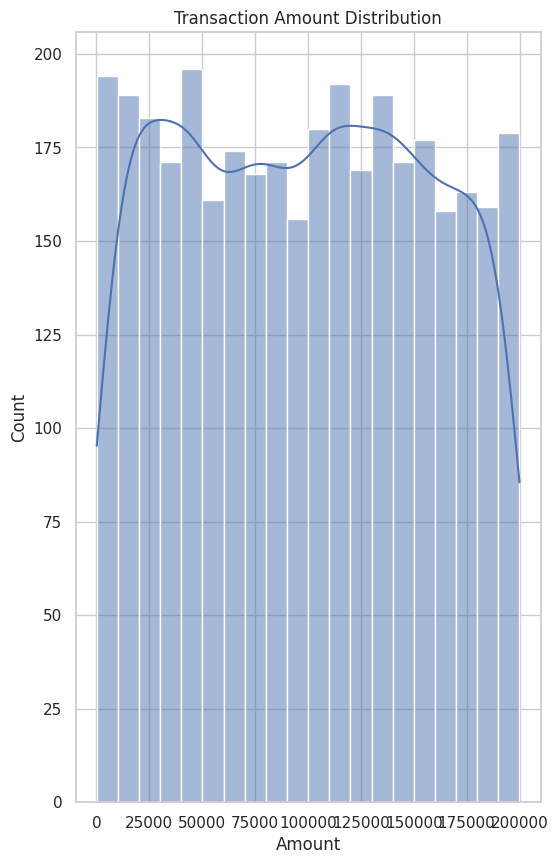

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(6,10))
sns.histplot(df["Amount"], bins=20, kde=True)
plt.title("Transaction Amount Distribution")

plt.show()

In [ ]:
#monthwise max transaction amount
df.groupby(df["Transaction_Date"].dt.month)["Amount"].max()

,Amount
Transaction_Date,
1,199691
2,199141
3,199066
4,198748
5,198518
6,199089
7,198800
8,198621
9,199647


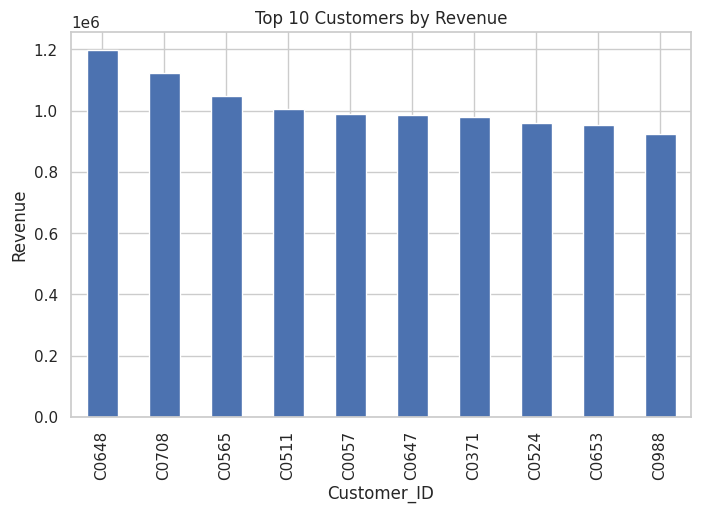

In [ ]:
# tOP 10 CUSTOMERS WITH TOTAL AMOUNT
top10 = df.groupby("Customer_ID")["Amount"].sum().nlargest(10)

plt.figure(figsize=(8,5))
top10.plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# count the no. of transactions on weekdays and weekends
df['Day_Name'] = df['Transaction_Date'].dt.day_name()
df['Is_Weekend'] = df['Transaction_Date'].dt.weekday >= 5
df.groupby('Is_Weekend')['Transaction_ID'].count()

,Transaction_ID
Is_Weekend,
False,2486
True,1014


In [ ]:
# Channel wise total transaction amount , average credit score
df.groupby("Channel").agg({"Amount":"sum","Credit_Score":"mean"})

,Amount,Credit_Score
Channel,,
ATM,81851660,586.709753
Card,87642870,599.394649
NetBanking,85445722,596.956826
UPI,89461419,603.512849


In [ ]:
ad_pivot = pd.pivot_table(df,
                          values='Amount',
                          index=['City','Account_Type'],
                          columns=['Transaction_Type'],
                          aggfunc=['sum','mean'])
ad_pivot

sum                     mean               
Transaction_Type          Credit     Debit         Credit          Debit
City      Account_Type                                                  
Bangalore Current       16189262  16058053  101182.887500   93906.742690
          Savings       12672783  14755437   97482.946154  104648.489362
Chennai   Current       14041929  14266930   94877.898649   97053.945578
          Savings       13937826  13012059   94174.500000   94978.532847
Delhi     Current       12544693  13958626   97245.682171   96266.386207
          Savings       16646598  13866498  103395.018634  101215.313869
Hyderabad Current       13727840  13812402  105598.769231   95257.944828
          Savings       13554624  16289052   99666.352941   98126.819277
Mumbai    Current       13004590  14718600   92231.134752  105132.857143
          Savings       15673242  13489641   97957.762500  101425.872180
Pune      Current       13141423  16028368   97343.874074  100807.345912
          Savings       13532794  15478401   95301.366197   97348.433962

In [ ]:
#pivot table adding transaction type, channel asand city as column
#finding count of transacton and average credit score
ad_pivot1= pd.pivot_table(df,
                          values=['Transaction_ID','Credit_Score'],
                          index=['Transaction_Type','Channel'],
                          columns=['City'],
                          aggfunc={'Transaction_ID': 'count', 'Credit_Score': 'mean'})
ad_pivot1

Credit_Score                                      \
City                           Bangalore     Chennai       Delhi   Hyderabad   
Transaction_Type Channel                                                       
Credit           ATM          570.306667  578.323944  570.794872  601.090909   
                 Card         572.013699  596.320513  558.689189  604.059701   
                 NetBanking   595.179104  572.291139  547.227273  631.781818   
                 UPI          571.840000  607.132353  603.083333  617.115385   
Debit            ATM          593.083333  570.264151  597.962025  572.774648   
                 Card         637.548780  608.727273  614.895522  567.311688   
                 NetBanking   603.361111  629.343750  559.406250  580.187500   
                 UPI          601.527027  617.240506  601.666667  613.192771   

                                                    Transaction_ID          \
City                             Mumbai        Pune      Bangalore Chennai   
Transaction_Type Channel                                                     
Credit           ATM         598.256098  565.032787             75      71   
                 Card        583.268657  627.705882             73      78   
                 NetBanking  601.376623  630.385714             67      79   
                 UPI         595.240000  620.871795             75      68   
Debit            ATM         602.800000  616.278689             84      53   
                 Card        600.138889  617.511905             82      88   
                 NetBanking  620.222222  600.142857             72      64   
                 UPI         617.491525  578.304878             74      79   

                                                         
City                        Delhi Hyderabad Mumbai Pune  
Transaction_Type Channel                                 
Credit           ATM           78        66     82   61  
                 Card          74        67     67   68  
                 NetBanking    66        55     77   70  
                 UPI           72        78     75   78  
Debit            ATM           79        71     70   61  
                 Card          67        77     72   84  
                 NetBanking    64        80     72   91  
                 UPI           72        83     59   82